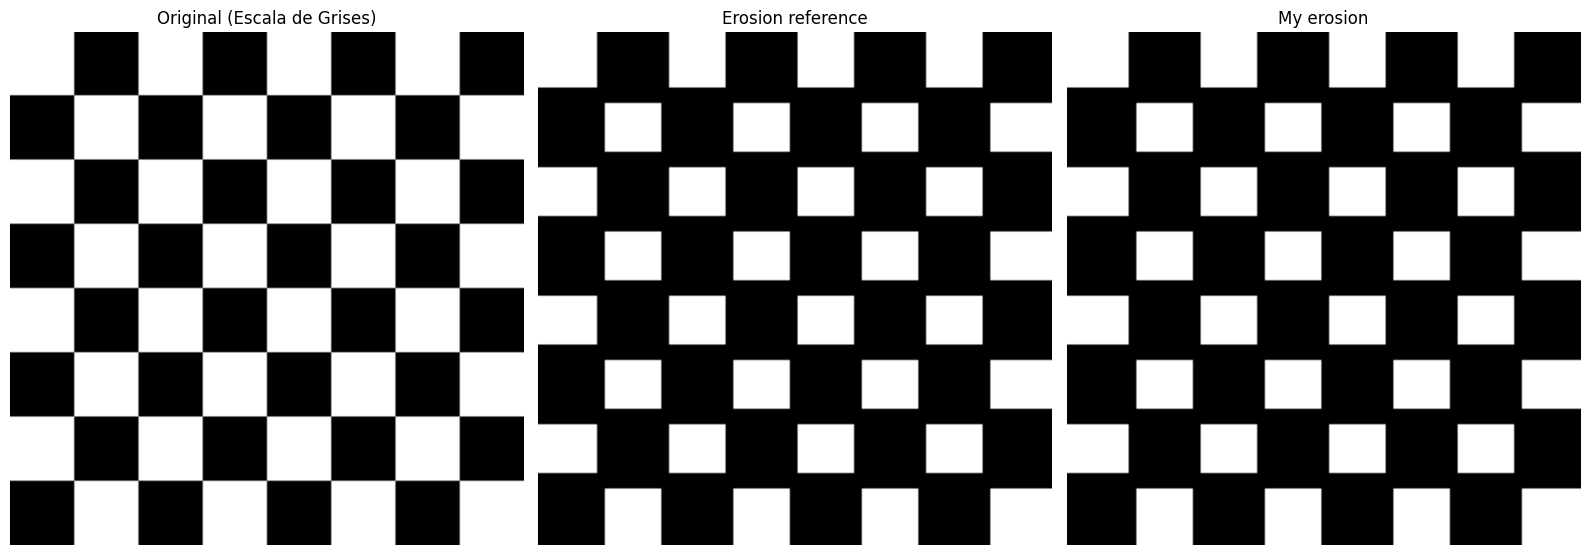

In [148]:
from skimage import data
from skimage import morphology
import matplotlib.pyplot as plt
import numpy as np

def erosion(img,se):
    width, height = img.shape
    se_width, se_height = se.shape
    cx, cy = se_width // 2, se_height // 2 # aproximate center if no point was given for the SE

    #print(f'SE: {se_width}x{se_height} -> on ({cx},{cy})')

    # Padding
    pad_top = cx
    pad_bottom = se_width - 1 - cx
    pad_left = cy
    pad_right = se_height - 1 - cy
    
    padded_img = np.pad(img, ((pad_top, pad_bottom), (pad_left, pad_right)), constant_values=1)

    result_img = np.zeros_like(img)
    #print(padded_img)

    for x in range(width):
        for y in range(height):
            mask = padded_img[x : x + se_width, y : y + se_height]
            
            # Filtramos solo donde el SE vale 1 y sacamos el mínimo
            masked_img = mask[se == 1]
            
            result_img[x, y] = np.min(masked_img) #basta con que un pixel del se no este incluido (que donde decia 1 en el SE sea 0 en la imagen)
    return result_img


img = data.checkerboard()
img = (img > 128).astype(np.uint8)
#img = np.array([
#    [ 1, 1, 1, 1],
#    [ 1, 1, 1, 1],
#    [ 1, 0, 0, 1],
#    [ 1, 1, 1, 1]
#])

structuring_element = np.array([
    [ 1, 1, 1],
    [ 1, 1, 1],
    [ 1, 1, 1]
])
structuring_element = np.array([
    [ 1, 1, 1, 1],
    [ 1, 0, 0, 1],
    [ 1, 0, 0, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
])

my_erosion = erosion(img,structuring_element)

img_erosion = morphology.erosion(img, structuring_element)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(img_erosion, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Erosion reference')
axes[1].axis('off')

axes[2].imshow(my_erosion, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('My erosion')
axes[2].axis('off')

plt.tight_layout()
plt.show()


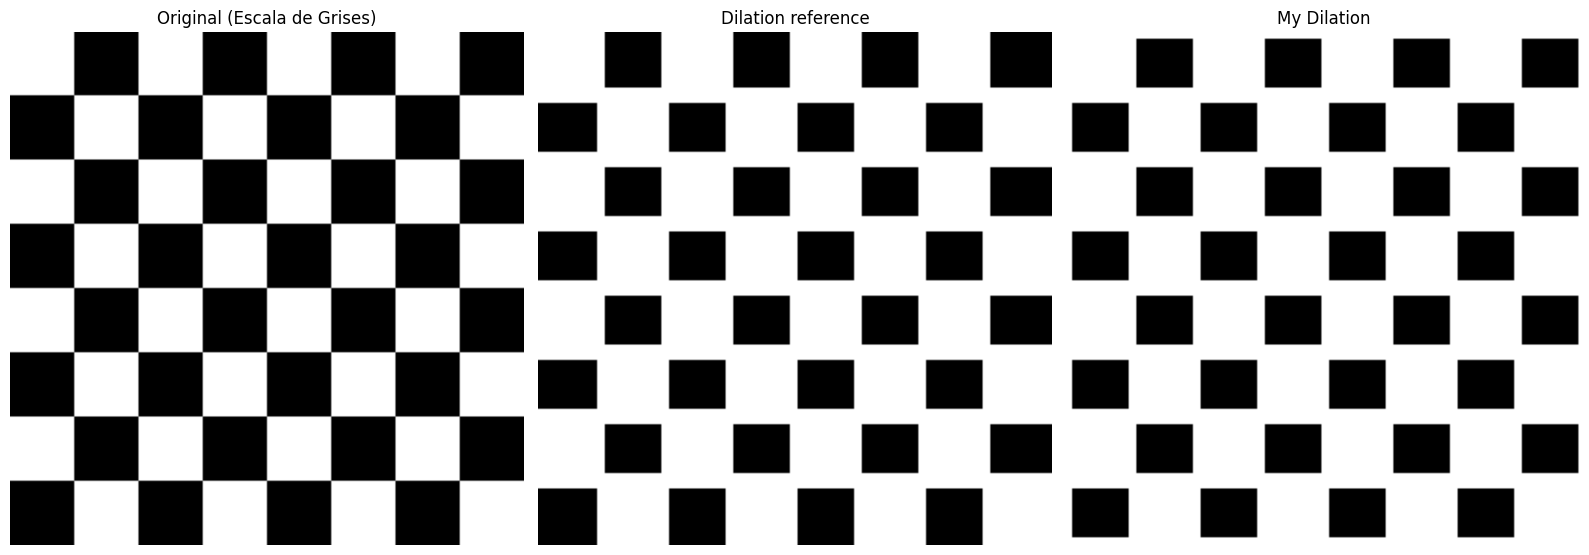

In [149]:
from skimage import data
from skimage import morphology
import matplotlib.pyplot as plt
import numpy as np

def dilation(img,se):
    width, height = img.shape
    se_width, se_height = se.shape
    cx, cy = se_width // 2, se_height // 2 # aproximate center if no point was given for the SE

    #print(f'SE: {se_width}x{se_height} -> on ({cx},{cy})')

    # Padding
    pad_top = cx
    pad_bottom = se_width - 1 - cx
    pad_left = cy
    pad_right = se_height - 1 - cy
    
    padded_img = np.pad(img, ((pad_top, pad_bottom), (pad_left, pad_right)), constant_values=1)

    result_img = np.zeros_like(img)
    #print(padded_img)

    for x in range(width):
        for y in range(height):
            mask = padded_img[x : x + se_width, y : y + se_height]
            
            # Filtramos solo donde el SE vale 1 y sacamos el mínimo
            masked_img = mask[se == 1]
            
            result_img[x, y] = np.max(masked_img) #basta con que un pixel del SE interseccion la imagen sea 1, osea podemos buscar el maximo
    return result_img


img = data.checkerboard()
img = (img > 128).astype(np.uint8)
#img = np.array([
#    [ 1, 1, 1, 1],
#    [ 1, 1, 1, 1],
#    [ 1, 0, 0, 1],
#    [ 1, 1, 1, 1]
#])

structuring_element = np.array([
    [ 1, 1, 1],
    [ 1, 1, 1],
    [ 1, 1, 1]
])
structuring_element = np.array([
    [ 1, 1, 1, 1],
    [ 1, 0, 0, 1],
    [ 1, 0, 0, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
])

my_dilation = dilation(img,structuring_element)


img_dilation = morphology.dilation(img, structuring_element)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
#
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(img_dilation, cmap='gray')
axes[1].set_title('Dilation reference')
axes[1].axis('off')

axes[2].imshow(my_dilation, cmap='gray')
axes[2].set_title('My Dilation')
axes[2].axis('off')

plt.tight_layout()
plt.show()


In [150]:
from skimage import util, io

# Utilizamos un tipo de dato con mayor precision para no tener problemas en la convolucion
img1 = util.img_as_ubyte(io.imread("./DB1_B/101_1.tif", as_gray=True))
img1 = (img1 > 150).astype(np.uint8)

img2 = util.img_as_ubyte(io.imread("./DB1_B/101_1.tif", as_gray=True))
img2 = (img2 > 150).astype(np.uint8)
img3 = util.img_as_ubyte(io.imread("./DB1_B/101_8.tif", as_gray=True))
img3 = (img3 > 150).astype(np.uint8)

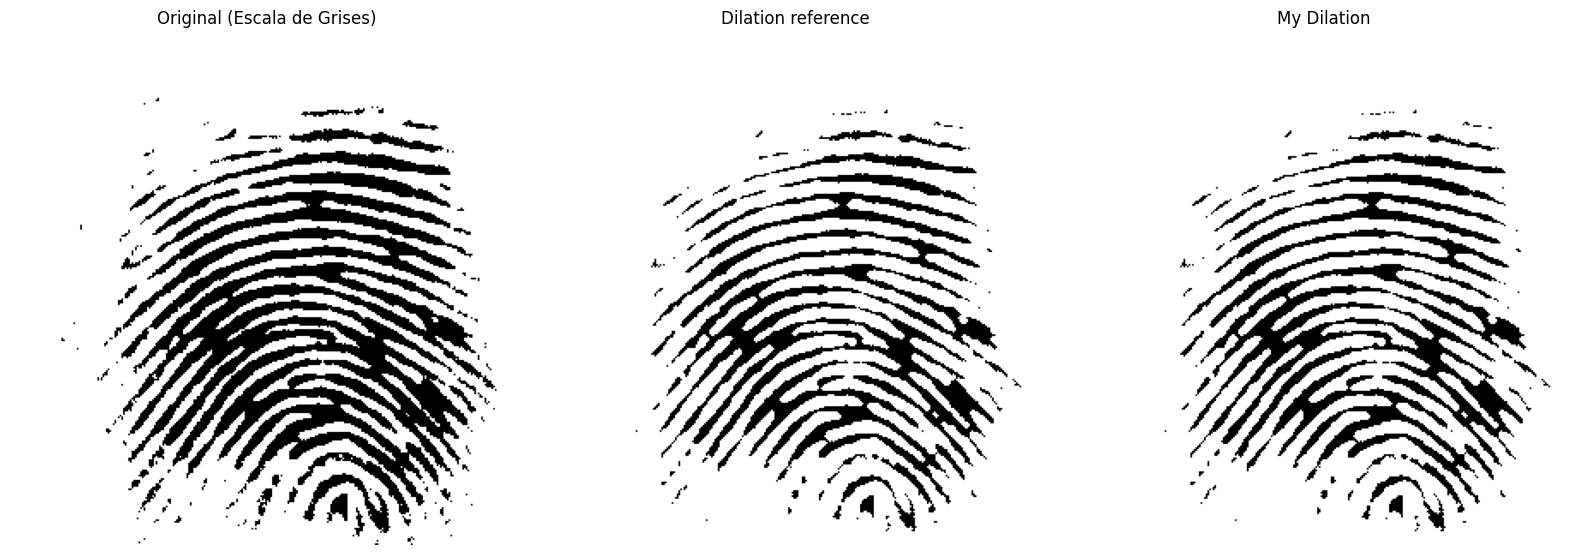

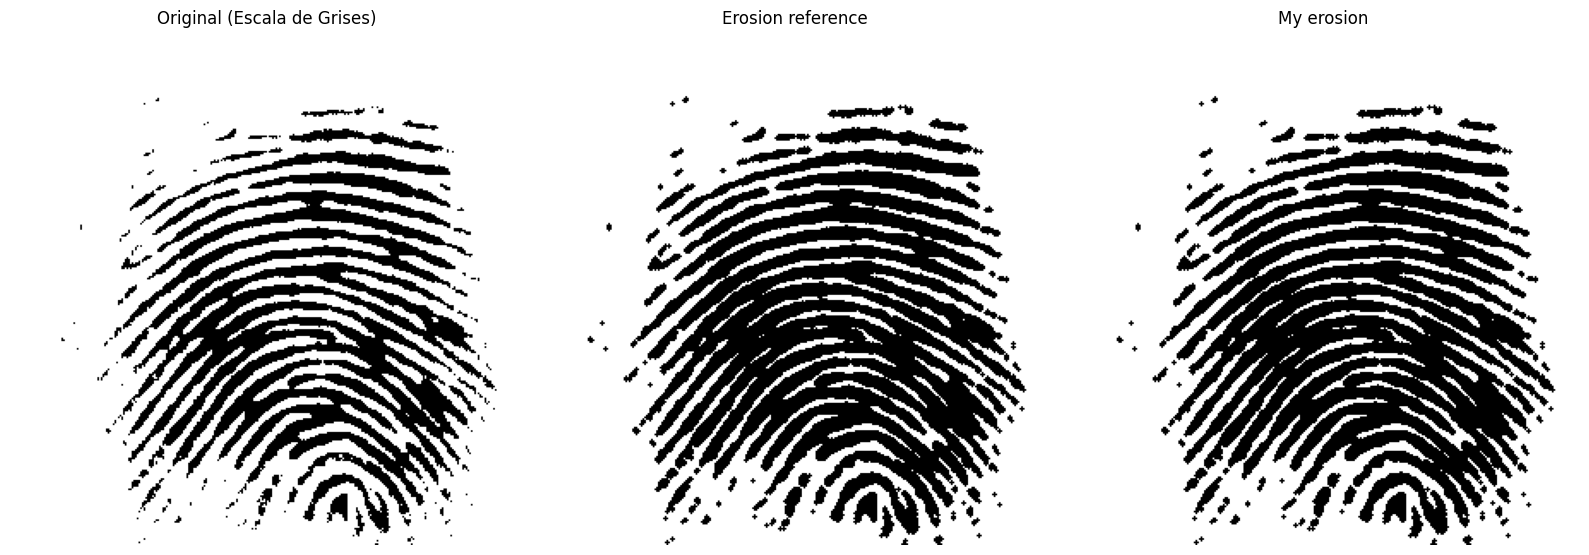

In [151]:
img=img1
structuring_element = np.array([
    [ 0, 1, 0,],
    [ 1, 1, 1,],
    [ 0, 1, 0,],
])

my_dilation = dilation(img,structuring_element)
img_dilation = morphology.dilation(img, structuring_element)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
#
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(img_dilation, cmap='gray')
axes[1].set_title('Dilation reference')
axes[1].axis('off')

axes[2].imshow(my_dilation, cmap='gray')
axes[2].set_title('My Dilation')
axes[2].axis('off')

plt.tight_layout()
plt.show()

#####
my_erosion = erosion(img,structuring_element)
img_erosion = morphology.erosion(img, structuring_element)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(img_erosion, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Erosion reference')
axes[1].axis('off')

axes[2].imshow(my_erosion, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('My erosion')
axes[2].axis('off')

plt.tight_layout()
plt.show()


# EXTRACTION OF CONNECTED COMPONENTS

In [152]:
from skimage import util, io, morphology, data
import matplotlib.pyplot as plt
import numpy as np


def extract_single_component(img, seed_point, se):
    X = np.zeros_like(img)
    X[seed_point] = 1
    
    # Ponemos un punto, la semilla, y dilatamos enmascarando con la imagen original, terminamos cuando no haya nada nuevo
    while True:
        X_prev = X.copy()
        dilated = morphology.dilation(X_prev, se)
        X = (dilated & img)
        if np.array_equal(X, X_prev):
            break
    return X



def label_all_connected_components(img, se=np.ones((3, 3))):
    working_img = img.copy() # Copia que vamos a ir "borrando"
    labeled_img = np.zeros_like(img, dtype=np.int32) # Imagen final con etiquetas
    
    label_counter = 1 # El primer objeto será el 1, el segundo el 2...
    height, width = working_img.shape
        
    # 1. Escanear toda la imagen píxel por píxel
    for y in range(height):
        for x in range(width):
            # Y determina la fila, y x la columna, por eso queda y,x para acceder en la matriz 
            # Al encontrar el primer pixel blanco (foreground) detectamos el primer componente
            if working_img[y, x] == 1:
                seed_point = (y, x)
                
                component = extract_single_component(working_img, seed_point, se)
                
                # Guardamos el componente con un valor diferente
                labeled_img[component == 1] = label_counter
                
                # Borramos el componente para evitar encontrarlo devuelta
                working_img[component == 1] = 0
                
                label_counter += 1
                
    return labeled_img, label_counter - 1


Connected component       | No. of pixels in connected comp
----------------------------------------------------------------------
01                        | 1818
02                        | 840
03                        | 392
04                        | 92
05                        | 18
06                        | 73
07                        | 55
08                        | 1
09                        | 1
10                        | 21
11                        | 2
12                        | 161
13                        | 1
14                        | 127



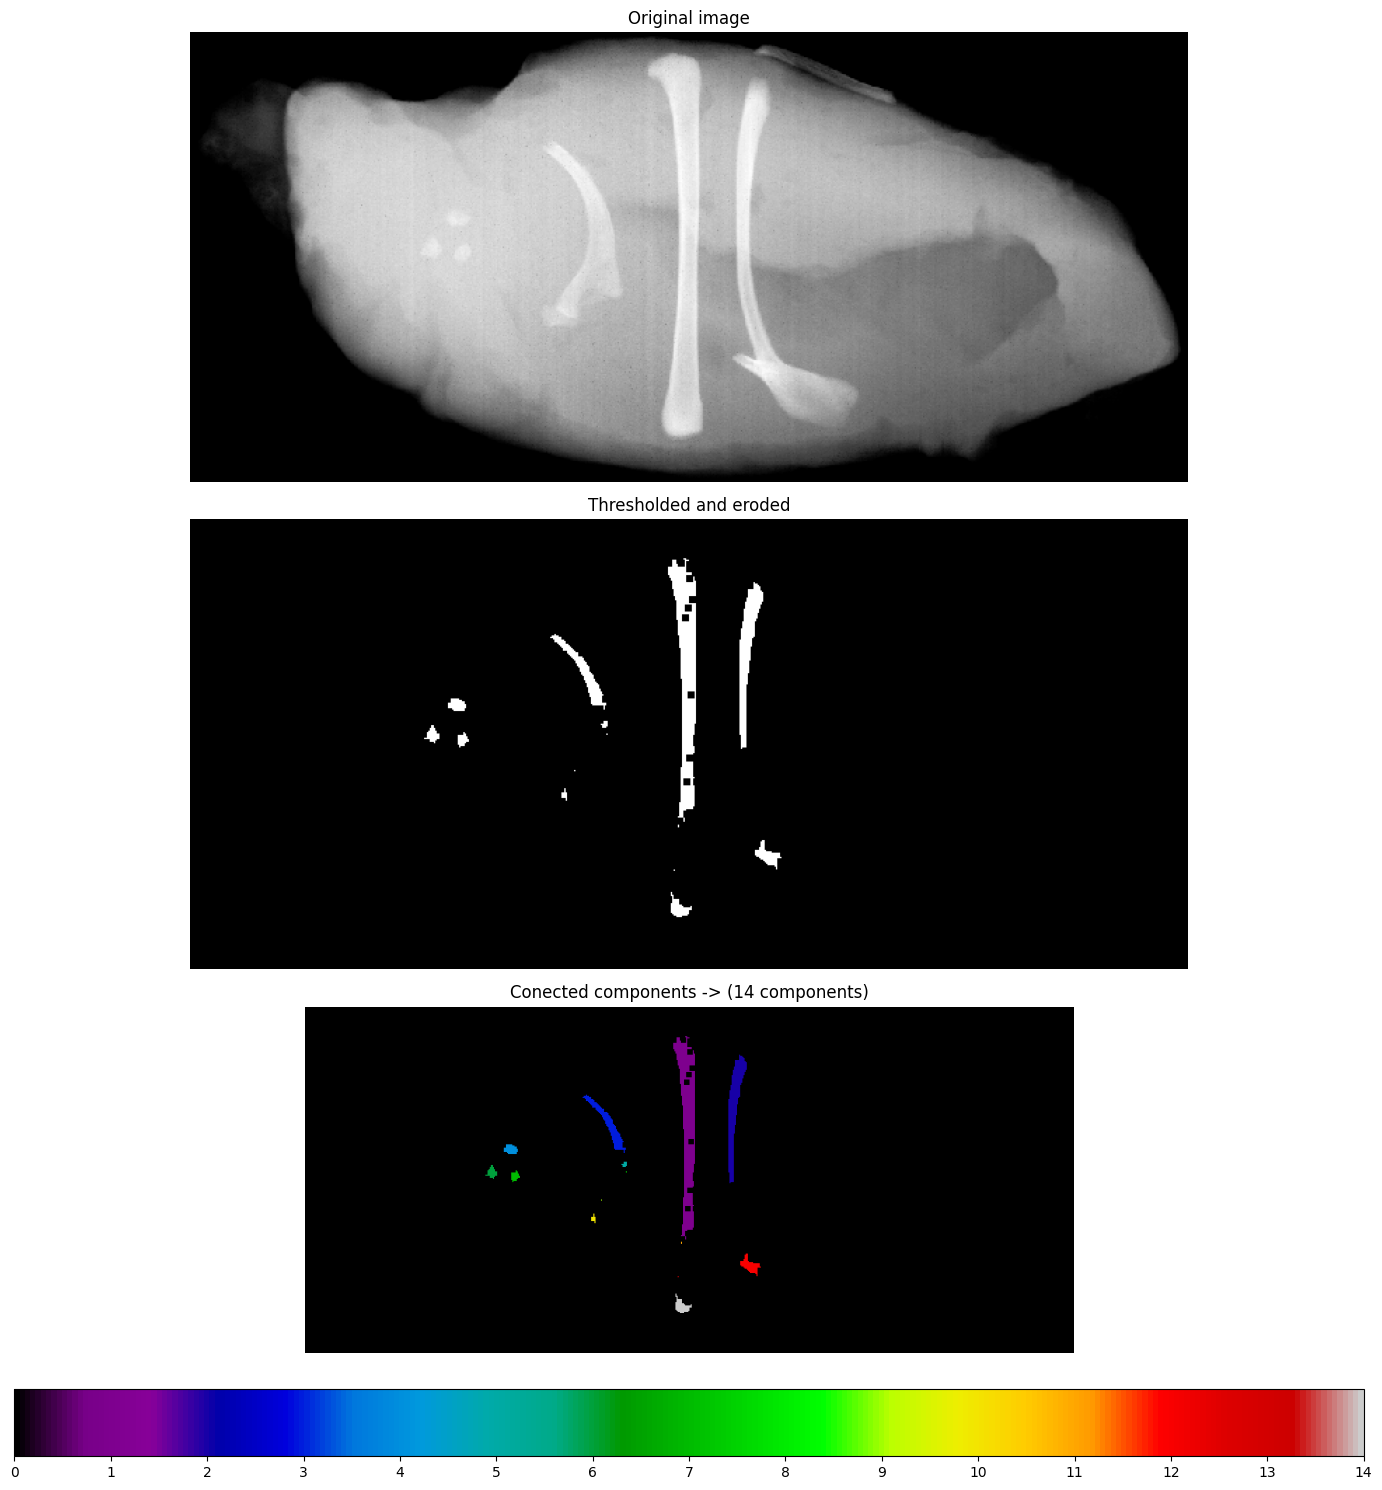

In [153]:
img_original = util.img_as_ubyte(io.imread("./book_example_images/Fig0918(a)(Chickenfilet with bones).tif", as_gray=True))
img_bin = (img_original > 195).astype(np.uint8)

se_5x5 = np.ones((5, 5), dtype=np.uint8)
img_eroded = morphology.erosion(img_bin, se_5x5) 
treated_img = img_eroded


labeled_result, total_objects = label_all_connected_components(treated_img)

# Tabla de componentes conexos
print("="*70)
print(f"{'Connected component':<25} | No. of pixels in connected comp")
print("-" * 70)
for i in range(1, total_objects + 1):
    pixels_count = np.sum(labeled_result == i)
    print(f"{i:02d}{'':<23} | {pixels_count}")
print("="*70 + "\n")


fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Original image')
axes[0].axis('off')

axes[1].imshow(treated_img, cmap='gray')
axes[1].set_title('Thresholded and eroded')
axes[1].axis('off')

cax = axes[2].imshow(labeled_result, cmap='nipy_spectral')
axes[2].set_title(f'Conected components -> ({total_objects} components)')
axes[2].axis('off')

fig.colorbar(cax, ax=axes[2], ticks=range(total_objects + 1), 
             orientation='horizontal', pad=0.08)

plt.tight_layout()
plt.show()

Connected component       | No. of pixels in connected comp
----------------------------------------------------------------------
01                        | 73091
02                        | 1
03                        | 18
04                        | 22
05                        | 1440
06                        | 1
07                        | 1
08                        | 1
09                        | 39
10                        | 52
11                        | 38
12                        | 164
13                        | 1
14                        | 81
15                        | 25
16                        | 2
17                        | 220
18                        | 2
19                        | 35
20                        | 39
21                        | 9
22                        | 10
23                        | 42



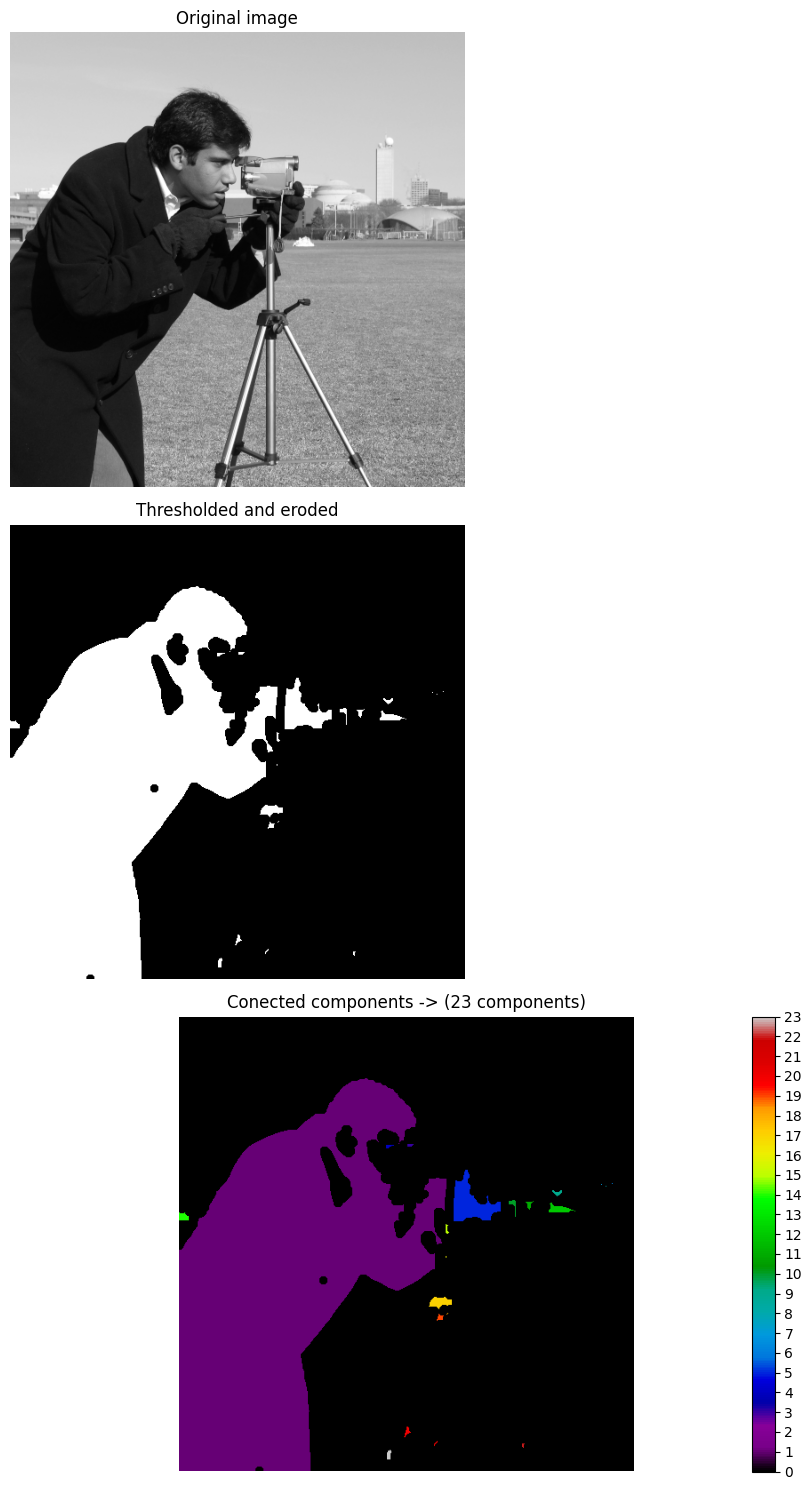

In [154]:
img_original = data.camera()
neg = 255 - img_original # negativo
img_bin = (neg > 110).astype(np.uint8)

se_5x5 = np.ones((5, 5), dtype=np.uint8)
se_disk = morphology.disk(2) #5x5 pero redondeado
img_eroded = morphology.erosion(img_bin, se_5x5) 
img_eroded = morphology.erosion(img_eroded, se_disk) 
img_dilation = morphology.dilation(img_eroded, se_disk) 
treated_img = img_eroded


labeled_result, total_objects = label_all_connected_components(treated_img)

# Tabla de componentes conexos
print("="*70)
print(f"{'Connected component':<25} | No. of pixels in connected comp")
print("-" * 70)
for i in range(1, total_objects + 1):
    pixels_count = np.sum(labeled_result == i)
    print(f"{i:02d}{'':<23} | {pixels_count}")
print("="*70 + "\n")


### Show example
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Original image')
axes[0].axis('off')

axes[1].imshow(treated_img, cmap='gray')
axes[1].set_title('Thresholded and eroded')
axes[1].axis('off')

# camera dependiendo el valor de umbral puede tener muchas componentes, podria usarse `from skimage.color import label2rgb`

cax = axes[2].imshow(labeled_result, cmap='nipy_spectral')
axes[2].set_title(f'Conected components -> ({total_objects} components)')
axes[2].axis('off')
fig.colorbar(cax, ax=axes[2], ticks=range(total_objects + 1), pad=0.08)

plt.tight_layout()
plt.show()

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Connected component       | No. of pixels in connected comp
----------------------------------------------------------------------
01                        | 8
02                        | 30
03                        | 5
04                        | 14
05                        | 11
06                        | 5
07                        | 202
08                        | 13
09                        | 182
10                        | 28
11                        | 719
12                        | 14
13                        | 672
14                        | 34
15                        | 5
16                        | 189
17                        | 1880
18                        | 44
19                        | 44
20                        | 5
21                        | 2074
22                        | 5
23                        | 19
24                        | 20
25

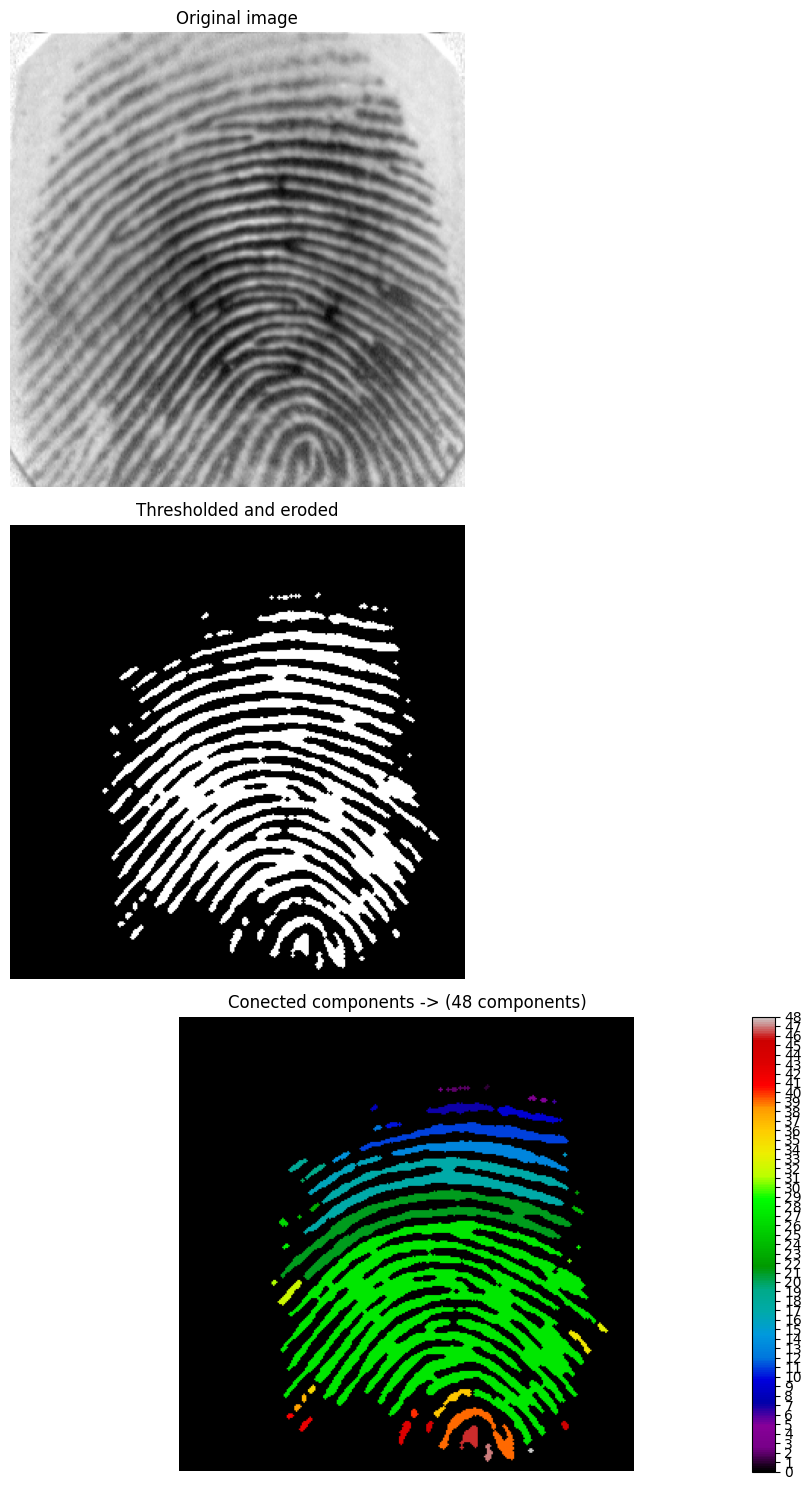

In [155]:
img_original = util.img_as_ubyte(io.imread("./DB1_B/101_1.tif", as_gray=True))
img_bin = (img_original < 150).astype(np.uint8)
print(img_bin)

se_disk = morphology.disk(1)
img_dilation = morphology.dilation(img_bin, se_disk) 
img_eroded = morphology.erosion(img_dilation, se_disk) 
img_eroded = morphology.erosion(img_eroded, se_disk) 
img_dilation = morphology.dilation(img_eroded, se_disk) 
treated_img = img_dilation

labeled_result, total_objects = label_all_connected_components(treated_img)

# Tabla de componentes conexos
print("="*70)
print(f"{'Connected component':<25} | No. of pixels in connected comp")
print("-" * 70)
for i in range(1, total_objects + 1):
    pixels_count = np.sum(labeled_result == i)
    print(f"{i:02d}{'':<23} | {pixels_count}")
print("="*70 + "\n")


### Show example
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Original image')
axes[0].axis('off')

axes[1].imshow(treated_img, cmap='gray')
axes[1].set_title('Thresholded and eroded')
axes[1].axis('off')

# camera dependiendo el valor de umbral puede tener muchas componentes, podria usarse `from skimage.color import label2rgb`

cax = axes[2].imshow(labeled_result, cmap='nipy_spectral')
axes[2].set_title(f'Conected components -> ({total_objects} components)')
axes[2].axis('off')
fig.colorbar(cax, ax=axes[2], ticks=range(total_objects + 1), pad=0.08)

plt.tight_layout()
plt.show()